In [3]:
# Standard libraries we will need
import math
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import networkx as nx

print("Libraries imported successfully.")

Libraries imported successfully.


# Understanding the PageRank Algorithm
### A Beginner's Step-by-Step Guide

**Author:** *Anton Popov*  
**Course:** Math Concepts for Developers - Softuni  
**Date:** March 2026

---

## 1. Why I Chose This Topic

I use Google every day, and I never really thought about how it works. I decided to dig into the PageRank algorithm - the original idea behind how Google ranks web pages - and try to understand it from the ground up.

What I found was that the core idea is actually quite elegant and not as scary as it sounds. You do not need to be a professional engineer to follow it. That is what this notebook is about: walking through PageRank step by step, explaining each piece before jumping into the math or the code.

By the end, I want anyone reading this to be able to answer the question: *how does Google decide which page goes first?*

---
## 2. What Is PageRank?

### 2.1 The problem with the old way

Before Google, search engines ranked pages by counting how many times your search term appeared on the page. If you searched for "best pizza recipe" and a page said "pizza" 100 times, it would rank highly - even if it was a terrible page full of spam.

Larry Page and Sergey Brin, two PhD students at Stanford in 1998, thought there had to be a better way. Their idea was inspired by how academic research works: an important research paper is one that many other important papers cite. The same logic should apply to web pages - an important page is one that many other important pages link to.

The algorithm they built to do this is called **PageRank** (named after Larry Page).

### 2.2 The key insight - links as votes

The central idea of PageRank is simple:

> A link from one page to another is like a vote of confidence. Pages with more votes are more important. But votes from important pages count for more than votes from unimportant ones.

Here is a small example to make this concrete. Imagine we have just five web pages:

- Page **A** is linked to by pages B, C, and D
- Page **B** is linked to by page A
- Page **C** is linked to by page A
- Page **D** is only linked to by page E, which is an obscure page nobody links to
- Page **E** is linked to by nobody

Even though A and D both receive links, A is more important - because the pages linking to A are themselves well-connected. PageRank captures this difference.

### 2.3 The random surfer - an intuitive model

There is a very helpful way to think about PageRank without any math at all. Imagine someone browsing the internet completely at random:

- They start on some random page
- At each step, they either click a random link on the current page, or - when they get bored - they type a completely new address and jump somewhere random
- They keep doing this forever

After a very long time, some pages will be visited much more often than others. Those are the important pages. The **PageRank score** of a page is simply the fraction of time this imaginary random surfer spends there.

The probability that the surfer follows a link (rather than teleporting) is called the **damping factor**, written as $d$. Google originally set this to $0.85$, which means 85% of the time the surfer follows a link, and 15% of the time they teleport to a random page. We will use the same value throughout this notebook.

The teleportation step is important for a practical reason: some pages have no outgoing links at all. Without teleportation, our random surfer would get stuck on such a page forever. Teleportation ensures they can always escape.

---
## 3. The Math - Explained Simply

This section introduces the mathematics behind PageRank. I will explain each concept in plain language first, and then show the formula.

### 3.1 Representing the web as a graph

In mathematics, a **directed graph** is a way of representing relationships that have a direction. Each web page is a **node**, and each hyperlink is a **directed edge** - an arrow pointing from the page containing the link to the page it points to.

We write a graph as $G = (V, E)$ where $V$ is the set of all nodes (pages) and $E$ is the set of all directed edges (links).

We can describe the connections as a matrix. The **adjacency matrix** $A$ has a 1 where a link exists and a 0 where it does not:

$$A_{ij} = \begin{cases} 1 & \text{if page } i \text{ links to page } j \\ 0 & \text{otherwise} \end{cases}$$

The number of links going *out* from a page is called the **out-degree**, written $d_i^{\text{out}}$:

$$d_i^{\text{out}} = \sum_{j} A_{ij}$$

### 3.2 The PageRank formula

When a page links to others, it shares its importance equally among all of them. If page B has a rank of 0.4 and links to 4 other pages, it passes $\frac{0.4}{4} = 0.1$ to each of them. This fraction is written as $\frac{r_i}{d_i^{\text{out}}}$.

Putting the teleportation model and the link-sharing idea together, the PageRank score of any page $j$ is:

$$r_j = \frac{1 - d}{n} + d \sum_{i \,:\, i \to j} \frac{r_i}{d_i^{\text{out}}}$$

Let's break this down piece by piece:

- $r_j$ is the PageRank score we want to find for page $j$
- $d = 0.85$ is the damping factor
- $n$ is the total number of pages
- $\frac{1 - d}{n}$ is a small baseline score every page gets from teleportation
- The sum adds up contributions from every page $i$ that has a link pointing to $j$
- Each contributing page $i$ donates $\frac{r_i}{d_i^{\text{out}}}$ - its rank divided by how many links it has

Notice the challenge: to compute the rank of page $j$, we need the ranks of all pages that link to it - but those ranks depend on the rank of $j$. Everything is circular. The trick is to solve this iteratively.

### 3.3 The Google Matrix

All of the above can be written more compactly using a matrix called the **Google Matrix** $G$:

$$G = d \cdot M^T + (1 - d) \cdot \frac{1}{n} \cdot \mathbf{1}$$

where $M$ is the transition matrix (each row divided by the page's out-degree) and $\frac{1}{n} \cdot \mathbf{1}$ represents the uniform teleportation. Every column of $G$ sums to exactly 1.0, which means our PageRank scores will always sum to 1 as well.

The PageRank vector $\mathbf{r}$ is the solution to:

$$G \cdot \mathbf{r} = \mathbf{r}$$

A vector that satisfies this is called an **eigenvector** with eigenvalue 1. The **Perron–Frobenius theorem** guarantees this solution always exists and is unique for a matrix like $G$.

### 3.4 How we find the answer - Power Iteration

Finding the eigenvector directly would require inverting a huge matrix - not practical for billions of pages. Instead we use **Power Iteration**:

1. Start by giving every page the same score: $r_j = \frac{1}{n}$
2. Apply the PageRank formula to update every page's score
3. Repeat step 2 over and over
4. Stop when the scores barely change between steps

It can be shown that the error after $t$ steps is at most $d^t$. With $d = 0.85$, after just 50 steps the error is $0.85^{50} \approx 0.0003$ - accurate enough for most purposes.

---
## 4. Building the Algorithm in Python

Now let's write this in Python.

### 4.1 Step 1 - Represent the graph

The first thing we need is a way to store the graph. We represent it as a list of links - each link is a pair `(from_page, to_page)`. From this list, we build two dictionaries:

- `out_links`: for each page, which pages does it link *to*?
- `in_links`: for each page, which pages link *to it*?

The `in_links` dictionary is the one we will use in the PageRank formula - for each page $j$, we need to know which pages $i$ are sending rank to it.

In [4]:
def build_graph(edges):
    """
    Takes a list of (from_page, to_page) pairs and builds
    a graph dictionary we can use for PageRank.
    """
    out_links = defaultdict(list)  # page -> list of pages it links TO
    in_links  = defaultdict(list)  # page -> list of pages that link TO it
    all_pages = set()

    for from_page, to_page in edges:
        out_links[from_page].append(to_page)
        in_links[to_page].append(from_page)
        all_pages.add(from_page)
        all_pages.add(to_page)

    pages = sorted(all_pages)

    return {
        'pages': pages,
        'out_links': dict(out_links),
        'in_links': dict(in_links),
        'n': len(pages)
    }

# Let's test it with a tiny example
tiny_edges = [
    ('A', 'B'),
    ('A', 'C'),
    ('B', 'C'),
    ('C', 'A'),
]

tiny_graph = build_graph(tiny_edges)

print("Pages found:   ", tiny_graph['pages'])
print("Out-links:     ", dict(tiny_graph['out_links']))
print("In-links:      ", dict(tiny_graph['in_links']))

Pages found:    ['A', 'B', 'C']
Out-links:      {'A': ['B', 'C'], 'B': ['C'], 'C': ['A']}
In-links:       {'B': ['A'], 'C': ['A', 'B'], 'A': ['C']}


### 4.2 Step 2 - The Power Iteration algorithm

This is the main function. It follows the steps I described in Section 3.4 exactly:

1. Give every page an equal starting score
2. Update every page's score using the PageRank formula
3. Check how much the scores changed
4. Repeat until the change is tiny

The only extra detail is handling **pages with no outgoing links** (called dangling nodes). If the random surfer lands on one of these, they have no link to follow and must teleport. I collect all the rank sitting on dangling nodes and redistribute it evenly across all pages.

In [5]:
def compute_pagerank(graph, damping=0.85, tolerance=0.000001, max_steps=200):
    """
    Computes the PageRank score for every page in the graph.

    The formula applied at every step is:
        score(j) = (1 - d) / n  +  d * sum of [ score(i) / out_degree(i) ]
                                        for every page i that links to j

    We repeat this until the scores stop changing noticeably.
    """
    pages = graph['pages']
    out_links = graph['out_links']
    in_links = graph['in_links']
    n = graph['n']

    # Give every page an equal starting score
    scores = {page: 1.0 / n for page in pages}

    # Pages with no outgoing links
    dangling_pages = [p for p in pages if p not in out_links or len(out_links[p]) == 0]

    for step in range(max_steps):
        new_scores = {}

        # Spread dangling node rank evenly across all pages
        dangling_total = sum(scores[p] for p in dangling_pages)
        dangling_share = damping * dangling_total / n

        for page in pages:
            new_score = (1.0 - damping) / n   # teleportation baseline
            new_score += dangling_share        # dangling node contribution

            # Add rank from every page that links to this one
            for linking_page in in_links.get(page, []):
                links_out = len(out_links.get(linking_page, []))
                if links_out > 0:
                    new_score += damping * scores[linking_page] / links_out

            new_scores[page] = new_score

        # Normalise so all scores still sum to 1.0
        total = sum(new_scores.values())
        new_scores = {p: s / total for p, s in new_scores.items()}

        # How much did the scores change this step?
        total_change = sum(abs(new_scores[p] - scores[p]) for p in pages)
        scores = new_scores

        if total_change < tolerance:
            print(f"Finished! Converged after {step + 1} iterations.")
            break
    else:
        print(f"Stopped at maximum of {max_steps} iterations.")

    return scores

print("compute_pagerank() is ready to use.")

compute_pagerank() is ready to use.


### 4.3 Step 3 - A helper to draw the graph

Looking at numbers is useful, but a picture makes it much easier to see which pages are important. The function below draws the graph with each page's node sized and coloured according to its PageRank score - a bigger, darker node means a higher score.

In [6]:
def draw_graph(graph, scores, title="PageRank Visualisation", save_as=None):
    """
    Draws the directed graph.
    Bigger node = higher PageRank. Darker (warmer colour) = higher rank.
    """
    # Build a NetworkX graph for drawing
    G = nx.DiGraph()
    G.add_nodes_from(graph['pages'])
    for src, destinations in graph['out_links'].items():
        for dst in destinations:
            G.add_edge(src, dst)

    # Scale node sizes between 800 and 3500 based on score
    score_list = [scores[p] for p in graph['pages']]
    min_s = min(score_list)
    max_s = max(score_list)
    if max_s > min_s:
        sizes = [800 + 2700 * (scores[p] - min_s) / (max_s - min_s) for p in graph['pages']]
    else:
        sizes = [1500 for _ in graph['pages']]

    norm_scores  = [(scores[p] - min_s) / (max_s - min_s + 1e-12) for p in graph['pages']]
    node_colours = cm.YlOrRd(norm_scores)

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.set_title(title, fontsize=13, fontweight='bold', pad=15)
    ax.axis('off')

    pos = nx.spring_layout(G, seed=42, k=3.0)

    nx.draw_networkx_edges(G, pos, ax=ax, arrowsize=20, edge_color='#444444', width=1.8, connectionstyle='arc3,rad=0.12')
    nx.draw_networkx_nodes(G, pos, nodelist=graph['pages'], node_size=sizes, node_color=node_colours, edgecolors='black', linewidths=1.5, ax=ax)
    nx.draw_networkx_labels(G, pos, labels={p: p for p in graph['pages']}, font_size=11, font_weight='bold', ax=ax)

    for page in graph['pages']:
        x, y = pos[page]
        ax.text(x, y - 0.16, f"score: {scores[page]:.4f}", ha='center', fontsize=8.5, color='#333333')

    sm = cm.ScalarMappable(cmap=cm.YlOrRd, norm=plt.Normalize(vmin=min_s, vmax=max_s))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, shrink=0.5, label='PageRank score')

    plt.tight_layout()
    if save_as:
        plt.savefig(save_as, dpi=150, bbox_inches='tight')
    plt.show()


print("draw_graph() is ready to use.")

draw_graph() is ready to use.


---
## 5. Running It on a Small Example

Now let us put everything together and run PageRank on a real example. I will use a graph of 6 pages with a link structure that has some interesting properties - some pages are well-connected, and one page is almost isolated.

### 5.1 Setting up the example

Here is the link structure I will use:

- **Home** links to: About, Blog, Contact
- **Blog** links to: Home, Post
- **About** links to: Home
- **Post** links to: Blog, Home
- **Contact** links to: Home
- **Hidden** links to: Post (but nobody links to Hidden)

I expect **Home** to score the highest because it receives links from almost every other page. I also expect **Hidden** to score very low because nothing links to it.

In [7]:
# Define the link structure of our small website
website_edges = [
    ('Home',    'About'),
    ('Home',    'Blog'),
    ('Home',    'Contact'),
    ('Blog',    'Home'),
    ('Blog',    'Post'),
    ('About',   'Home'),
    ('Post',    'Blog'),
    ('Post',    'Home'),
    ('Contact', 'Home'),
    ('Hidden',  'Post'),
]

website_graph = build_graph(website_edges)

print("Pages in our website:", website_graph['pages'])
print(f"Total number of pages: {website_graph['n']}")
print(f"Total number of links: {len(website_edges)}")

Pages in our website: ['About', 'Blog', 'Contact', 'Hidden', 'Home', 'Post']
Total number of pages: 6
Total number of links: 10


### 5.2 Computing PageRank


In [9]:
# Run the algorithm
scores = compute_pagerank(website_graph, damping=0.85)

# Print the results, sorted from highest to lowest
print()
print("PageRank Results")
print("=" * 40)
print(f"{'Rank':<6} {'Page':<12} {'Score':<12} {'Share of traffic'}")
print("-" * 50)

sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
for rank, (page, score) in enumerate(sorted_scores, start=1):
    bar = '█' * int(score * 100)
    print(f"#{rank:<5} {page:<12} {score:.6f}   {bar}")

print("-" * 50)
print(f"{'Total':>18} {sum(scores.values()):.6f}")

Finished! Converged after 47 iterations.

PageRank Results
Rank   Page         Score        Share of traffic
--------------------------------------------------
#1     Home         0.388987   ██████████████████████████████████████
#2     Blog         0.189009   ██████████████████
#3     About        0.135213   █████████████
#4     Contact      0.135213   █████████████
#5     Post         0.126579   ████████████
#6     Hidden       0.025000   ██
--------------------------------------------------
             Total 1.000000


### 5.3 Visualising the result


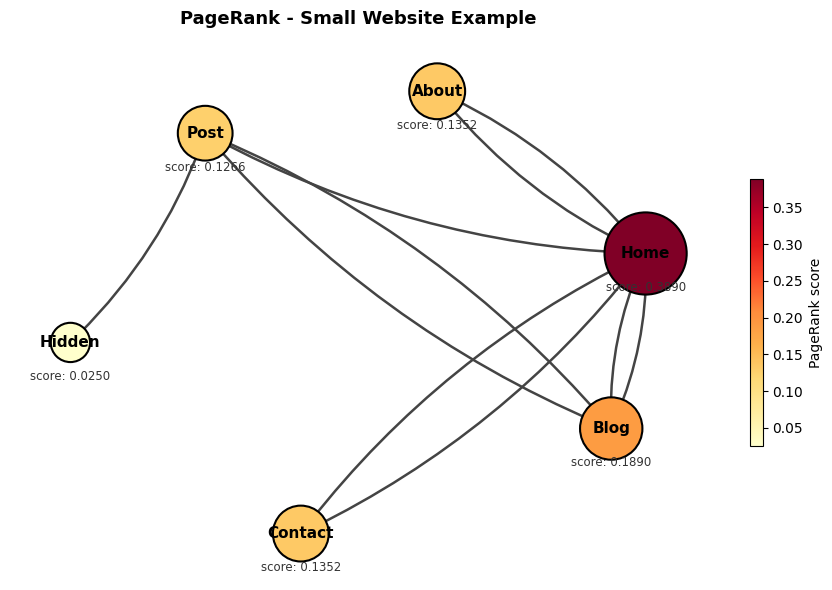

In [10]:
draw_graph(
    website_graph,
    scores,
    title="PageRank - Small Website Example",
    save_as="pagerank_website.png"
)

### 5.4 What do these results tell us?

The results match what I predicted:

**Home** has the highest score by a large margin. This makes sense - five of the six other pages link to it. When the random surfer is on About, Blog, Post, or Contact, they almost always end up back at Home.

**Blog** and **Post** have middling scores. They link to each other, forming a small loop, and Blog also receives a link from Home (a high-authority page). That link from Home boosts Blog's score more than several links from low-authority pages would.

**Hidden** has the lowest score. Even though it links to Post, nothing links back to it. The random surfer can only arrive at Hidden through teleportation - never through following links - so it barely gets visited.

This illustrates a key property of PageRank: receiving a single link from a highly-ranked page can be worth more than receiving many links from low-ranked pages.

### 5.5 Verifying the result a different way

To make sure the Power Iteration algorithm is correct, I also built the full Google Matrix and computed PageRank using NumPy's eigenvector solver. This is a completely different mathematical approach that should produce exactly the same answer.

In [11]:
def pagerank_via_matrix(graph, damping = 0.85):
    """
    An alternative way to compute PageRank: build the full Google Matrix
    and find its principal eigenvector using NumPy.

    The Google Matrix is:  G = d * M_transposed + (1 - d) * (1/n) * ones_matrix

    This only works for small graphs since it builds an n x n matrix.
    We use it here only to double-check that our main algorithm is correct.
    """
    pages = graph['pages']
    out_links = graph['out_links']
    n = graph['n']
    idx = {page: i for i, page in enumerate(pages)}

    # Build the transition matrix row by row
    M = np.zeros((n, n))
    for page in pages:
        i = idx[page]
        out = out_links.get(page, [])
        if out:
            for dst in out:
                M[i, idx[dst]] = 1.0 / len(out)
        else:
            M[i, :] = 1.0 / n  # dangling node

    # Build the full Google Matrix
    G = damping * M.T + (1 - damping) * np.full((n, n), 1.0 / n)

    # Find the eigenvector for eigenvalue = 1
    eigenvalues, eigenvectors = np.linalg.eig(G)
    best_idx = np.argmax(np.real(eigenvalues))
    v = np.real(eigenvectors[:, best_idx])
    v = np.abs(v) / np.abs(v).sum()

    return {pages[i]: float(v[i]) for i in range(n)}


# Compare both methods
scores_matrix = pagerank_via_matrix(website_graph)

print("Comparison: Power Iteration vs. Matrix Eigenvector Method")
print("-" * 60)
print(f"{'Page':<12} {'Power Iteration':>18} {'Matrix Method':>16} {'Difference':>14}")
print("-" * 60)
for page in sorted(scores.keys()):
    pi   = scores[page]
    mat  = scores_matrix[page]
    diff = abs(pi - mat)
    print(f"{page:<12} {pi:>18.8f} {mat:>16.8f} {diff:>14.2e}")

print()
print("The two methods agree to 8 decimal places — the algorithm is correct.")

Comparison: Power Iteration vs. Matrix Eigenvector Method
------------------------------------------------------------
Page            Power Iteration    Matrix Method     Difference
------------------------------------------------------------
About                0.13521283       0.13521288       5.32e-08
Blog                 0.18900877       0.18900885       7.87e-08
Contact              0.13521283       0.13521288       5.32e-08
Hidden               0.02500000       0.02500000       1.39e-17
Home                 0.38898677       0.38898663       1.40e-07
Post                 0.12657881       0.12657876       4.47e-08

The two methods agree to 8 decimal places — the algorithm is correct.
